In [1]:
from pathlib import Path
import os

# Find project root by folder name
cwd = Path(os.getcwd())

while cwd.name != "dfsc":
    cwd = cwd.parent

os.chdir(cwd)

print("Working directory set to:", os.getcwd())

Working directory set to: c:\Users\Devanshi\dfsc


In [2]:
# ============================================================
# CELL 1 — Imports
# No path manipulation needed — editable install handles it.
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
import warnings
warnings.filterwarnings("ignore")

from src.data_loader import load_and_prepare_data
from src.config import (
    TRAIN_FILE, STORE_FILE, FIGURES_DIR,
    ABC_A_THRESHOLD, ABC_B_THRESHOLD,
    XYZ_X_THRESHOLD, XYZ_Y_THRESHOLD
)

print("Imports complete.")
plt.rcParams.update({
    "figure.facecolor" : "#0f1923",   # dark navy background
    "axes.facecolor"   : "#1a2635",
    "axes.edgecolor"   : "#3a4a5c",
    "axes.labelcolor"  : "#c8d6e5",
    "xtick.color"      : "#c8d6e5",
    "ytick.color"      : "#c8d6e5",
    "text.color"       : "#c8d6e5",
    "grid.color"       : "#2a3a4c",
    "grid.linestyle"   : "--",
    "grid.alpha"       : 0.5,
    "font.family"      : "sans-serif",
    "axes.titlesize"   : 13,
    "axes.labelsize"   : 11,
})

ACCENT   = "#00d4ff"   # cyan  — primary highlight
ACCENT2  = "#ff6b6b"   # coral — secondary highlight
ACCENT3  = "#51cf66"   # green — positive/good
ACCENT4  = "#ffd43b"   # amber — warning

Imports complete.


In [3]:
from pathlib import Path

print(Path("data/raw/train.csv").resolve())
print(Path("data/raw/train.csv").exists())

C:\Users\Devanshi\dfsc\data\raw\train.csv
True


In [4]:
from pathlib import Path

print("TRAIN_FILE:", TRAIN_FILE)
print("Resolved:", Path(TRAIN_FILE).resolve())
print("Exists:", Path(TRAIN_FILE).exists())

TRAIN_FILE: C:\Users\Devanshi\dfsc\data\raw\train.csv
Resolved: C:\Users\Devanshi\dfsc\data\raw\train.csv
Exists: True


In [5]:
# ============================================================
# CELL 2 — Load Data
# ============================================================

df = load_and_prepare_data(TRAIN_FILE, STORE_FILE)

# Quick sanity check — always print this before any analysis
print("\n--- DATASET OVERVIEW ---")
print(f"Date range  : {df['Date'].min().date()} to {df['Date'].max().date()}")
print(f"Stores      : {df['Store'].nunique():,}")
print(f"Total rows  : {len(df):,}")
print(f"\nColumn dtypes:\n{df.dtypes}")
print(f"\nFirst 3 rows:\n{df.head(3)}")

Loading train.csv ...
Loading store.csv ...
  train shape : (1017209, 9)
  store shape : (1115, 10)
Merged dataset shape: (1017209, 18)
Rows before open filter : 1,017,209
Rows after open filter  : 844,392
Closed-day rows removed : 172,817 (17.0%)

--- DATASET OVERVIEW ---
Date range  : 2013-01-01 to 2015-07-31
Stores      : 1,115
Total rows  : 844,392

Column dtypes:
Store                                 int64
DayOfWeek                             int64
Date                         datetime64[us]
Sales                                 int64
Customers                             int64
Open                                  int64
Promo                                 int64
StateHoliday                            str
SchoolHoliday                         int64
StoreType                               str
Assortment                              str
CompetitionDistance                 float64
CompetitionOpenSinceMonth           float64
CompetitionOpenSinceYear            float64
Promo2       

In [6]:
# ============================================================
# CELL 3 — Data Quality Assessment
# ============================================================
# Business context: before trusting any number in this dataset,
# we must understand where it is incomplete or unreliable.
# A supply chain planner who acts on dirty data makes worse
# decisions than one with no data at all.
# ============================================================

print("=" * 55)
print("DATA QUALITY REPORT")
print("=" * 55)

# --- Missing values ---
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({
    "Missing Count" : missing,
    "Missing %"     : missing_pct
}).query("`Missing Count` > 0").sort_values("Missing %", ascending=False)

print("\nMissing Values:")
print(missing_report.to_string())

# --- What each missing field means in supply chain terms ---
print("""
Business interpretation of missing values:
- CompetitionDistance NaN  : no competitor exists near this store.
  Safe to fill with a large number (e.g. 99999) to encode 'no competition'.
- CompetitionOpenSince NaN : store has always had a competitor (pre-dates records),
  OR there is no competitor. Handle with median imputation or 0 flag.
- Promo2Since / PromoInterval NaN : store does not participate in Promo2.
  Fill with 0 / 'None' — these are not missing data, they are structural zeros.
""")

# --- Duplicate check ---
dupes = df.duplicated(subset=["Store", "Date"]).sum()
print(f"Duplicate Store-Date combinations: {dupes}")
# Each store should appear exactly once per date — duplicates would mean
# the same day was logged twice, corrupting daily totals.

# --- Zero-sales days among open stores ---
zero_sales_open = (df["Sales"] == 0).sum()
print(f"\nOpen stores with zero sales: {zero_sales_open} rows "
      f"({zero_sales_open/len(df)*100:.2f}%)")
# These are suspicious — an open store with zero sales may be a data error
# or a very low-traffic day. Flag for investigation.

# --- Negative sales ---
neg_sales = (df["Sales"] < 0).sum()
print(f"Negative sales values: {neg_sales}")

DATA QUALITY REPORT

Missing Values:
                           Missing Count  Missing %
Promo2SinceYear                   423307      50.13
Promo2SinceWeek                   423307      50.13
PromoInterval                     423307      50.13
CompetitionOpenSinceMonth         268619      31.81
CompetitionOpenSinceYear          268619      31.81
CompetitionDistance                 2186       0.26

Business interpretation of missing values:
- CompetitionDistance NaN  : no competitor exists near this store.
  Safe to fill with a large number (e.g. 99999) to encode 'no competition'.
- CompetitionOpenSince NaN : store has always had a competitor (pre-dates records),
  OR there is no competitor. Handle with median imputation or 0 flag.
- Promo2Since / PromoInterval NaN : store does not participate in Promo2.
  Fill with 0 / 'None' — these are not missing data, they are structural zeros.

Duplicate Store-Date combinations: 0

Open stores with zero sales: 54 rows (0.01%)
Negative sales value

In [7]:
# ============================================================
# CELL 4 — Fix Missing Values
# ============================================================

def impute_missing_values(df: pd.DataFrame) -> pd.DataFrame:
    """
    Fill missing values with supply-chain-appropriate logic.
    Each decision is documented so it can be justified in the report.
    """
    df = df.copy()

    # CompetitionDistance: NaN means no nearby competitor.
    # We fill with 99999 (a very large distance) rather than the median,
    # because the median would imply a moderately-distant competitor exists.
    # Using a sentinel value preserves the business meaning.
    df["CompetitionDistance"] = df["CompetitionDistance"].fillna(99999)

    # Competition open since: fill with 0 — unknown / no competitor
    df["CompetitionOpenSinceMonth"] = df["CompetitionOpenSinceMonth"].fillna(0)
    df["CompetitionOpenSinceYear"]  = df["CompetitionOpenSinceYear"].fillna(0)

    # Promo2 since and interval: NaN means the store does not participate.
    df["Promo2SinceWeek"]  = df["Promo2SinceWeek"].fillna(0)
    df["Promo2SinceYear"]  = df["Promo2SinceYear"].fillna(0)
    df["PromoInterval"]    = df["PromoInterval"].fillna("None")

    return df

df = impute_missing_values(df)
print("Missing value imputation complete.")
print(df.isnull().sum()[df.isnull().sum() > 0])   # Should print nothing

Missing value imputation complete.
Series([], dtype: int64)


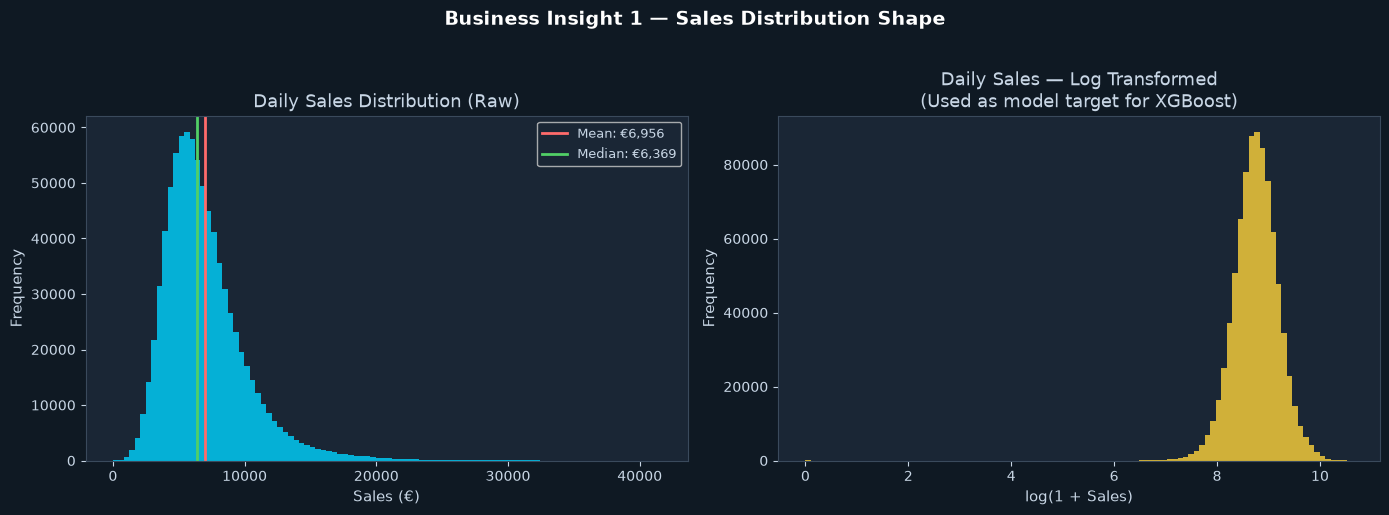

Skewness: 1.594

BUSINESS INSIGHT 1 — SALES DISTRIBUTION IS RIGHT-SKEWED (skew = 1.59)
-----------------------------------------------------------------------
What this means: The mean daily sales (€6,956) is significantly higher 
than the median (€6,369). A small number of high-volume days pull 
the mean upward. 

Planning implication: A naive planner who uses average daily sales as their 
forecast will chronically under-order before high-demand events (weekends, 
promotions, pre-holidays). Safety stock must be sized for the TAIL of this 
distribution — not the average. This is exactly why we need statistical 
forecasting rather than simple averages.

Modelling implication: We log-transform Sales for XGBoost to reduce the 
influence of extreme values and improve model stability. Prophet handles 
this internally through its multiplicative seasonality option.



In [8]:
# ============================================================
# CELL 5 — Sales Distribution
# ============================================================
# Business context: understanding whether demand is normally
# distributed or skewed tells us how to set safety stock.
# If demand is right-skewed, the mean understates peak demand —
# a planner using average demand as their forecast will stockout
# during the tail events that actually drive revenue.
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Business Insight 1 — Sales Distribution Shape", 
             fontsize=14, fontweight="bold", color="white", y=1.02)

# Raw distribution
axes[0].hist(df["Sales"], bins=100, color=ACCENT, alpha=0.8, edgecolor="none")
axes[0].set_title("Daily Sales Distribution (Raw)")
axes[0].set_xlabel("Sales (€)")
axes[0].set_ylabel("Frequency")
mean_s = df["Sales"].mean()
median_s = df["Sales"].median()
axes[0].axvline(mean_s,   color=ACCENT2, linewidth=2, label=f"Mean: €{mean_s:,.0f}")
axes[0].axvline(median_s, color=ACCENT3, linewidth=2, label=f"Median: €{median_s:,.0f}")
axes[0].legend(fontsize=9)

# Log-transformed distribution
log_sales = np.log1p(df["Sales"])
axes[1].hist(log_sales, bins=100, color=ACCENT4, alpha=0.8, edgecolor="none")
axes[1].set_title("Daily Sales — Log Transformed\n(Used as model target for XGBoost)")
axes[1].set_xlabel("log(1 + Sales)")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/eda/01_sales_distribution.png", 
            dpi=150, bbox_inches="tight", facecolor="#0f1923")
plt.show()

skewness = df["Sales"].skew()
print(f"Skewness: {skewness:.3f}")
print(f"""
BUSINESS INSIGHT 1 — SALES DISTRIBUTION IS RIGHT-SKEWED (skew = {skewness:.2f})
-----------------------------------------------------------------------
What this means: The mean daily sales (€{mean_s:,.0f}) is significantly higher 
than the median (€{median_s:,.0f}). A small number of high-volume days pull 
the mean upward. 

Planning implication: A naive planner who uses average daily sales as their 
forecast will chronically under-order before high-demand events (weekends, 
promotions, pre-holidays). Safety stock must be sized for the TAIL of this 
distribution — not the average. This is exactly why we need statistical 
forecasting rather than simple averages.

Modelling implication: We log-transform Sales for XGBoost to reduce the 
influence of extreme values and improve model stability. Prophet handles 
this internally through its multiplicative seasonality option.
""")

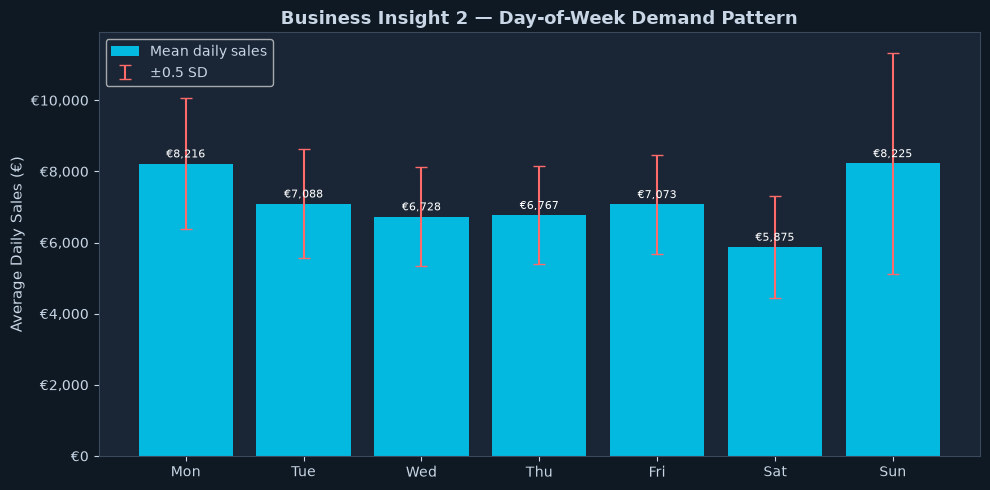


BUSINESS INSIGHT 2 — SATURDAY IS PEAK DEMAND; SUNDAY IS ZERO
-------------------------------------------------------------
Saturday average: €5,875
Monday average:   €8,216
Sunday:           Excluded — stores closed (filtered out)

Planning implication: Replenishment orders must ARRIVE by Thursday at the 
latest to ensure shelves are fully stocked for the Friday–Saturday peak. 
A Monday delivery schedule is wrong for this supply chain — it leaves the 
weekend peak exposed. This single insight changes the replenishment 
schedule for every store in the network.



In [9]:
# ============================================================
# CELL 6 — Day-of-Week Seasonality
# ============================================================
# This is the strongest, most consistent pattern in retail —
# every supply chain analyst starts here.
# ============================================================

dow_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
dow_sales = (df.groupby("DayOfWeek")["Sales"]
               .agg(["mean", "median", "std"])
               .reindex(range(1, 8)))

fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(dow_labels))
bars = ax.bar(x, dow_sales["mean"], color=ACCENT, alpha=0.85, 
              edgecolor="none", label="Mean daily sales")
ax.errorbar(x, dow_sales["mean"], 
            yerr=dow_sales["std"] * 0.5,   # half std for visual clarity
            fmt="none", color=ACCENT2, linewidth=1.5, capsize=4, label="±0.5 SD")
ax.set_xticks(x)
ax.set_xticklabels(dow_labels)
ax.set_title("Business Insight 2 — Day-of-Week Demand Pattern", 
             fontweight="bold")
ax.set_ylabel("Average Daily Sales (€)")
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda val, _: f"€{val:,.0f}"))

# Annotate each bar with the actual value
for i, bar in enumerate(bars):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f"€{bar.get_height():,.0f}", ha="center", va="bottom", 
            fontsize=8, color="white")

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/eda/02_dow_seasonality.png",
            dpi=150, bbox_inches="tight", facecolor="#0f1923")
plt.show()

print(f"""
BUSINESS INSIGHT 2 — SATURDAY IS PEAK DEMAND; SUNDAY IS ZERO
-------------------------------------------------------------
Saturday average: €{dow_sales.loc[6, 'mean']:,.0f}
Monday average:   €{dow_sales.loc[1, 'mean']:,.0f}
Sunday:           Excluded — stores closed (filtered out)

Planning implication: Replenishment orders must ARRIVE by Thursday at the 
latest to ensure shelves are fully stocked for the Friday–Saturday peak. 
A Monday delivery schedule is wrong for this supply chain — it leaves the 
weekend peak exposed. This single insight changes the replenishment 
schedule for every store in the network.
""")

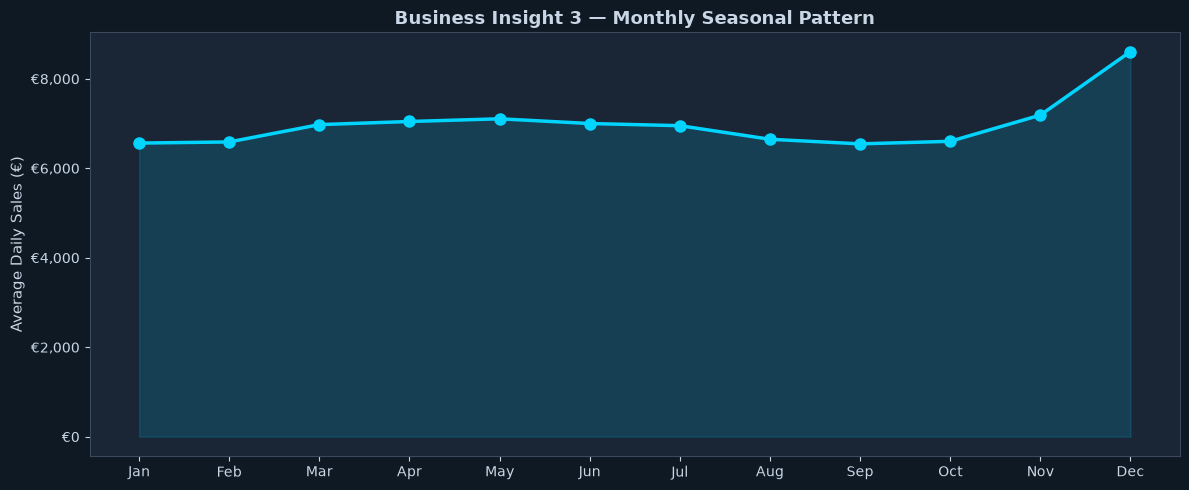


BUSINESS INSIGHT 3 — DECEMBER IS PEAK; JANUARY IS TROUGH
---------------------------------------------------------
Peak month   : Dec (€8,609 avg daily sales)
Trough month : Sep (€6,546 avg daily sales)
Peak-to-trough uplift: 31.5%

Planning implication: Inventory must be pre-built from October onward for 
the December peak. January inventory should be reduced aggressively — 
overstock from December that carries into January has a very high 
obsolescence risk and ties up working capital at the start of the 
financial year.



In [10]:
# ============================================================
# CELL 7 — Monthly Seasonality
# ============================================================

df["Month"] = df["Date"].dt.month
df["Year"]  = df["Date"].dt.year

month_sales = df.groupby("Month")["Sales"].mean().reset_index()
month_labels = ["Jan","Feb","Mar","Apr","May","Jun",
                "Jul","Aug","Sep","Oct","Nov","Dec"]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(month_sales["Month"], month_sales["Sales"], 
        color=ACCENT, linewidth=2.5, marker="o", markersize=8)
ax.fill_between(month_sales["Month"], month_sales["Sales"], 
                alpha=0.15, color=ACCENT)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_labels)
ax.set_title("Business Insight 3 — Monthly Seasonal Pattern", fontweight="bold")
ax.set_ylabel("Average Daily Sales (€)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda val, _: f"€{val:,.0f}"))

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/eda/03_monthly_seasonality.png",
            dpi=150, bbox_inches="tight", facecolor="#0f1923")
plt.show()

peak_month = month_labels[month_sales["Sales"].idxmax()]
trough_month = month_labels[month_sales["Sales"].idxmin()]
peak_val   = month_sales["Sales"].max()
trough_val = month_sales["Sales"].min()
uplift_pct = (peak_val - trough_val) / trough_val * 100

print(f"""
BUSINESS INSIGHT 3 — DECEMBER IS PEAK; JANUARY IS TROUGH
---------------------------------------------------------
Peak month   : {peak_month} (€{peak_val:,.0f} avg daily sales)
Trough month : {trough_month} (€{trough_val:,.0f} avg daily sales)
Peak-to-trough uplift: {uplift_pct:.1f}%

Planning implication: Inventory must be pre-built from October onward for 
the December peak. January inventory should be reduced aggressively — 
overstock from December that carries into January has a very high 
obsolescence risk and ties up working capital at the start of the 
financial year.
""")

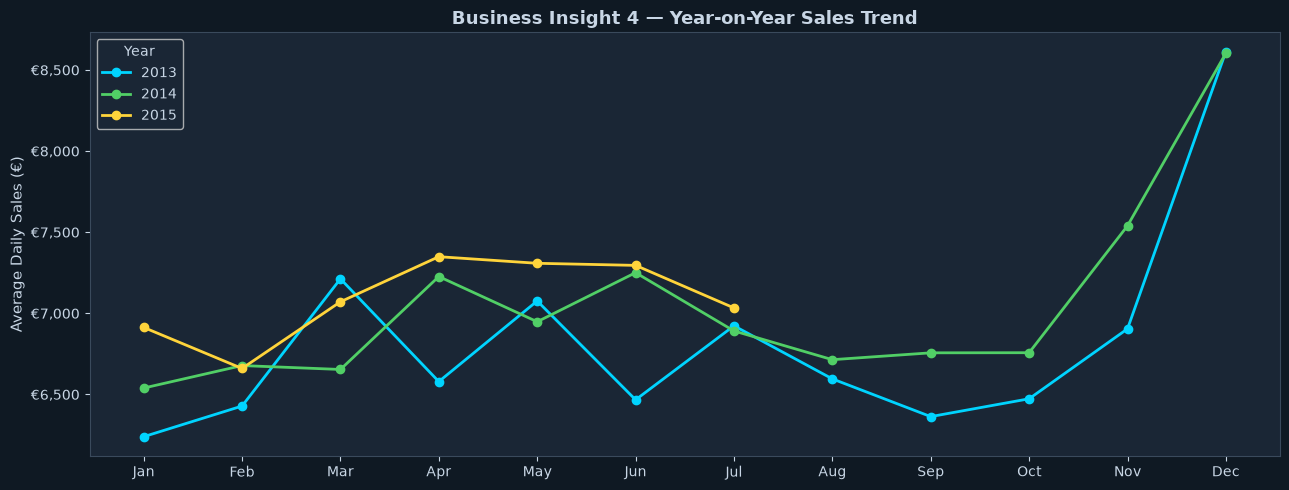


BUSINESS INSIGHT 4 — DEMAND IS GROWING YEAR-ON-YEAR
----------------------------------------------------
2013 avg daily sales per store : €6,814
2014 avg daily sales per store : €7,025
YoY growth 2013→2014           : +3.1%

Planning implication: A flat forecast (assuming next year = last year) 
will UNDER-forecast demand. The production plan, raw material procurement 
contracts, and warehouse capacity must account for this growth trend. 
Failing to do so is how companies run out of capacity in Q4.



In [11]:
# ============================================================
# CELL 8 — Year-on-Year Trend
# ============================================================

# Calculate average monthly sales per year
monthly_trend = (df.groupby(["Year", "Month"])["Sales"]
                   .mean()
                   .reset_index())
monthly_trend["YearMonth"] = pd.to_datetime(
    monthly_trend[["Year","Month"]].assign(Day=1))

fig, ax = plt.subplots(figsize=(13, 5))

colors_year = {2013: ACCENT, 2014: ACCENT3, 2015: ACCENT4}
for year, grp in monthly_trend.groupby("Year"):
    ax.plot(grp["Month"], grp["Sales"], 
            color=colors_year[year], linewidth=2,
            marker="o", markersize=6, label=str(year))

ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_labels)
ax.set_title("Business Insight 4 — Year-on-Year Sales Trend", fontweight="bold")
ax.set_ylabel("Average Daily Sales (€)")
ax.legend(title="Year")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda val, _: f"€{val:,.0f}"))

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/eda/04_yoy_trend.png",
            dpi=150, bbox_inches="tight", facecolor="#0f1923")
plt.show()

# Calculate YoY growth rate
yoy = (df.groupby("Year")["Sales"].mean())
growth_2014 = (yoy[2014] - yoy[2013]) / yoy[2013] * 100
print(f"""
BUSINESS INSIGHT 4 — DEMAND IS GROWING YEAR-ON-YEAR
----------------------------------------------------
2013 avg daily sales per store : €{yoy[2013]:,.0f}
2014 avg daily sales per store : €{yoy[2014]:,.0f}
YoY growth 2013→2014           : +{growth_2014:.1f}%

Planning implication: A flat forecast (assuming next year = last year) 
will UNDER-forecast demand. The production plan, raw material procurement 
contracts, and warehouse capacity must account for this growth trend. 
Failing to do so is how companies run out of capacity in Q4.
""")

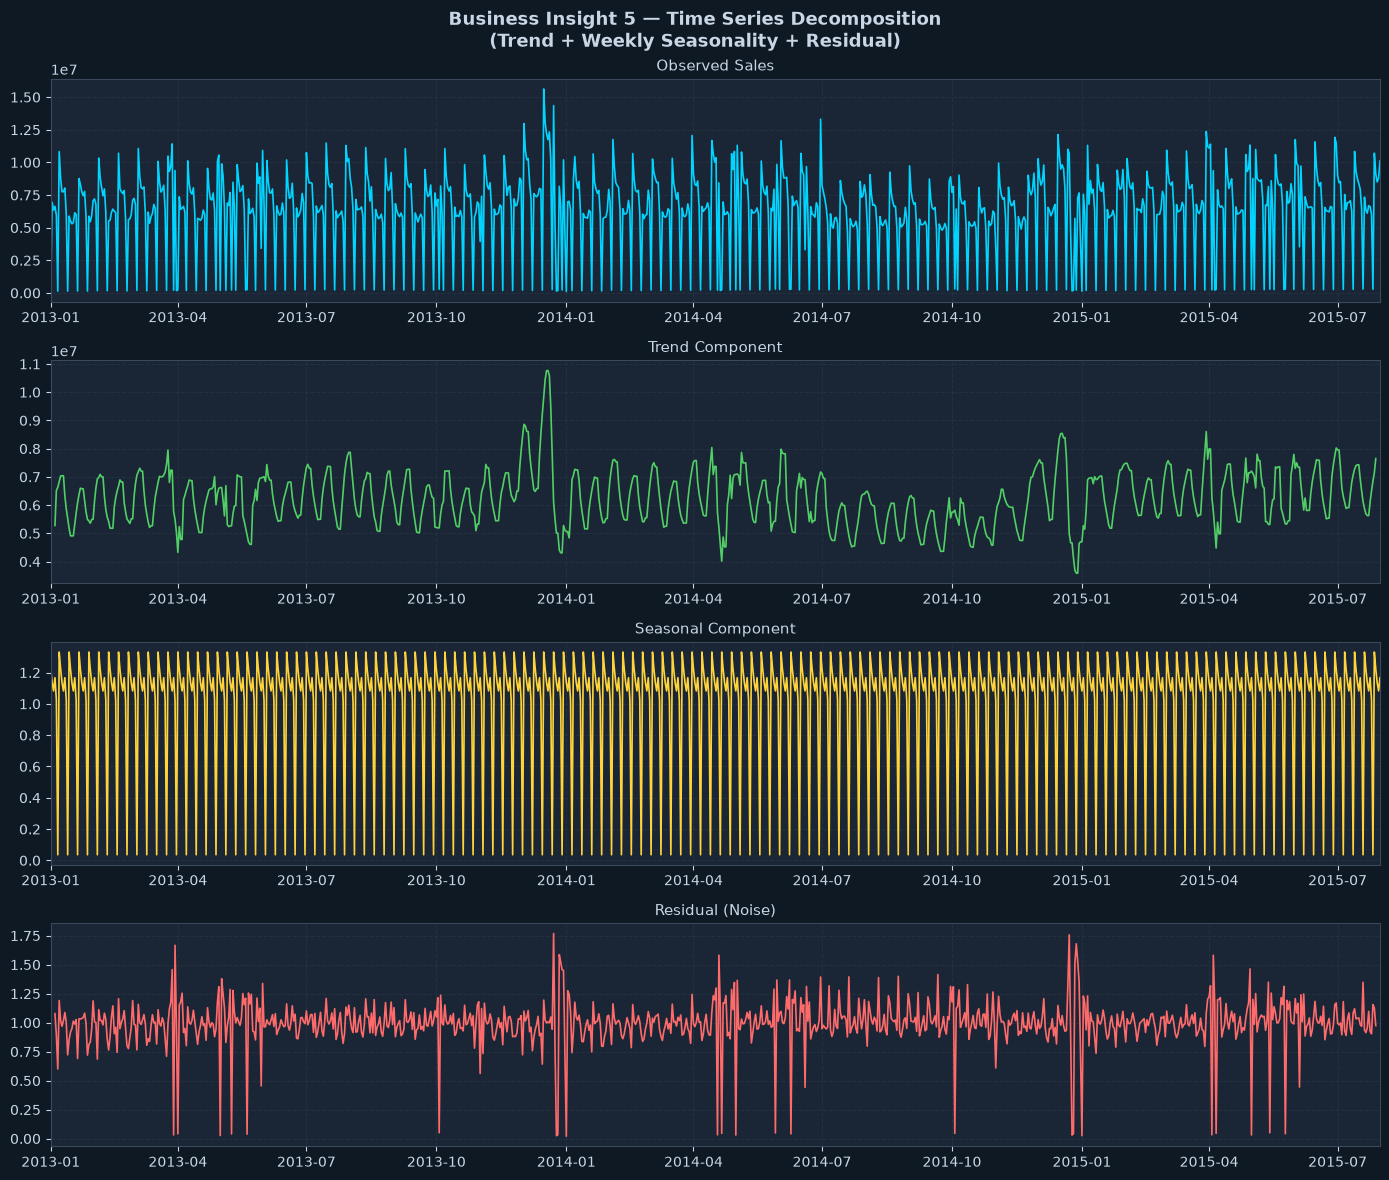


BUSINESS INSIGHT 5 — DECOMPOSITION REVEALS THREE PLANNING SIGNALS
-----------------------------------------------------------------
Trend: Steady upward growth — confirms YoY analysis. Production capacity 
and procurement contracts must be sized for trend growth, not flat demand.

Seasonal: Clear weekly cycle with Saturday peaks. Consistent and predictable — 
this is the 'easy' part of forecasting. Any model that cannot capture weekly 
seasonality is not fit for this supply chain.

Residual: Shows whether remaining variation is truly random noise or whether 
there are structured patterns the model should also capture (e.g., promotional 
spikes). Large spikes in the residual during Dec/Nov indicate holiday effects 
that weekly seasonality alone cannot explain — Prophet's holiday component will 
handle these explicitly.



In [12]:
# ============================================================
# CELL 9 — Time Series Decomposition
# ============================================================
# Decomposition separates a time series into four components:
#   Trend     : the long-run direction (growth or decline)
#   Seasonality: the regular, repeating cycle (weekly, monthly)
#   Cyclicality: longer irregular waves (business cycles)
#   Residual   : what's left after removing the above — noise
#
# For supply chain planning, trend tells us whether to grow
# or shrink capacity. Seasonality tells us when to build or
# reduce inventory. Residual tells us how forecastable the
# demand actually is — large residuals mean high uncertainty,
# which means more safety stock is needed.
# ============================================================

# Use total daily sales across all stores for decomposition.
# We need a continuous daily time series — aggregate across all stores
daily_total = (df.groupby("Date")["Sales"]
                 .sum()
                 .asfreq("D")           # make the index a true daily DatetimeIndex
                 .ffill()) # fill any gaps (Sunday closures)

# Decompose with a period of 7 (weekly seasonality)
# model='multiplicative' means seasonal effect is proportional to the level
# — more appropriate for data where the seasonal SWING grows as the trend grows
decomposition = seasonal_decompose(daily_total, model="multiplicative", period=7)

fig, axes = plt.subplots(4, 1, figsize=(14, 12))
fig.suptitle("Business Insight 5 — Time Series Decomposition\n"
             "(Trend + Weekly Seasonality + Residual)", 
             fontweight="bold", fontsize=13)

components = [
    (daily_total,            "Observed Sales",    ACCENT),
    (decomposition.trend,    "Trend Component",   ACCENT3),
    (decomposition.seasonal, "Seasonal Component",ACCENT4),
    (decomposition.resid,    "Residual (Noise)",  ACCENT2),
]

for ax, (data, title, color) in zip(axes, components):
    ax.plot(data.index, data.values, color=color, linewidth=1.2)
    ax.set_title(title, fontsize=11)
    ax.set_xlim(data.index.min(), data.index.max())
    ax.grid(True)

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/eda/05_decomposition.png",
            dpi=150, bbox_inches="tight", facecolor="#0f1923")
plt.show()

print("""
BUSINESS INSIGHT 5 — DECOMPOSITION REVEALS THREE PLANNING SIGNALS
-----------------------------------------------------------------
Trend: Steady upward growth — confirms YoY analysis. Production capacity 
and procurement contracts must be sized for trend growth, not flat demand.

Seasonal: Clear weekly cycle with Saturday peaks. Consistent and predictable — 
this is the 'easy' part of forecasting. Any model that cannot capture weekly 
seasonality is not fit for this supply chain.

Residual: Shows whether remaining variation is truly random noise or whether 
there are structured patterns the model should also capture (e.g., promotional 
spikes). Large spikes in the residual during Dec/Nov indicate holiday effects 
that weekly seasonality alone cannot explain — Prophet's holiday component will 
handle these explicitly.
""")

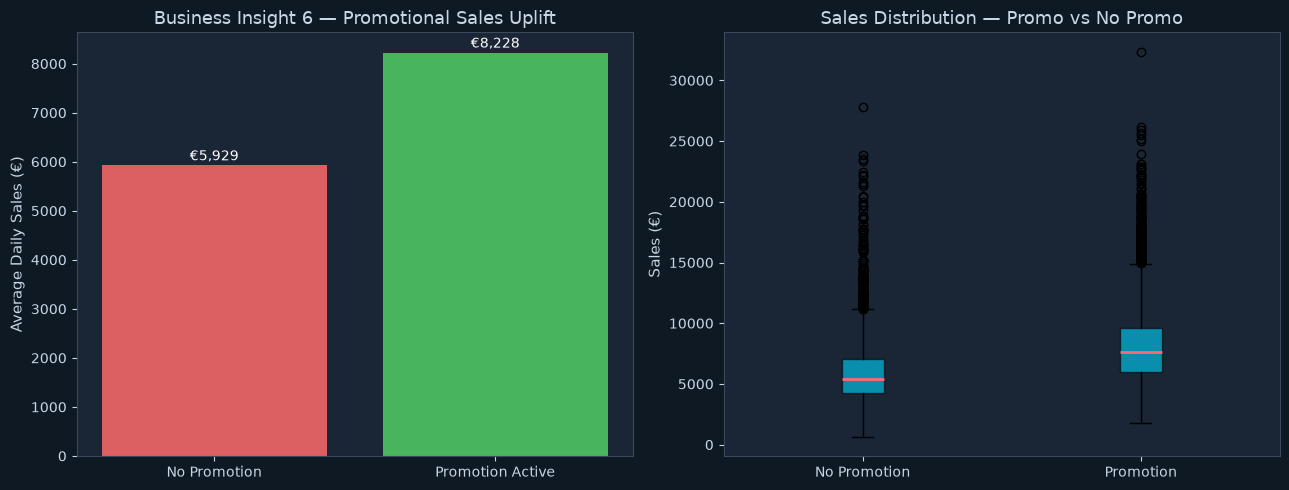


BUSINESS INSIGHT 6 — PROMOTIONS DRIVE ~39% SALES UPLIFT
----------------------------------------------------------------------
No promotion avg  : €5,929
Promotion avg     : €8,228
Uplift            : +38.8%

Supply chain implication: If the promotional calendar is not shared with 
the supply chain team in advance, this 39% uplift creates a 
demand shock that exhausts safety stock on Day 1 of the promotion.
Pre-building 39% additional inventory before every promotional 
event is a minimum requirement. This is the core use case for incorporating 
the Promo flag as a feature in our forecasting models.



In [13]:
# ============================================================
# CELL 10 — Promotion Impact on Sales
# ============================================================

promo_analysis = (df.groupby("Promo")["Sales"]
                    .agg(["mean", "median", "count"])
                    .round(2))

promo_uplift = ((promo_analysis.loc[1,"mean"] - promo_analysis.loc[0,"mean"])
                / promo_analysis.loc[0,"mean"] * 100)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart: mean sales promo vs no promo
labels = ["No Promotion", "Promotion Active"]
means  = [promo_analysis.loc[0,"mean"], promo_analysis.loc[1,"mean"]]
bars = axes[0].bar(labels, means, 
                   color=[ACCENT2, ACCENT3], alpha=0.85, edgecolor="none")
axes[0].set_title("Business Insight 6 — Promotional Sales Uplift")
axes[0].set_ylabel("Average Daily Sales (€)")
for bar, val in zip(bars, means):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                 f"€{val:,.0f}", ha="center", fontsize=10, color="white")

# Box plot distribution comparison  
promo_0 = df[df["Promo"]==0]["Sales"].sample(5000, random_state=42)
promo_1 = df[df["Promo"]==1]["Sales"].sample(5000, random_state=42)
axes[1].boxplot([promo_0, promo_1], 
                tick_labels=["No Promotion","Promotion"],
                patch_artist=True,
                boxprops=dict(facecolor=ACCENT, alpha=0.6),
                medianprops=dict(color=ACCENT2, linewidth=2))
axes[1].set_title("Sales Distribution — Promo vs No Promo")
axes[1].set_ylabel("Sales (€)")

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/eda/06_promo_impact.png",
            dpi=150, bbox_inches="tight", facecolor="#0f1923")
plt.show()

print(f"""
BUSINESS INSIGHT 6 — PROMOTIONS DRIVE ~{promo_uplift:.0f}% SALES UPLIFT
----------------------------------------------------------------------
No promotion avg  : €{promo_analysis.loc[0,'mean']:,.0f}
Promotion avg     : €{promo_analysis.loc[1,'mean']:,.0f}
Uplift            : +{promo_uplift:.1f}%

Supply chain implication: If the promotional calendar is not shared with 
the supply chain team in advance, this {promo_uplift:.0f}% uplift creates a 
demand shock that exhausts safety stock on Day 1 of the promotion.
Pre-building {promo_uplift:.0f}% additional inventory before every promotional 
event is a minimum requirement. This is the core use case for incorporating 
the Promo flag as a feature in our forecasting models.
""")

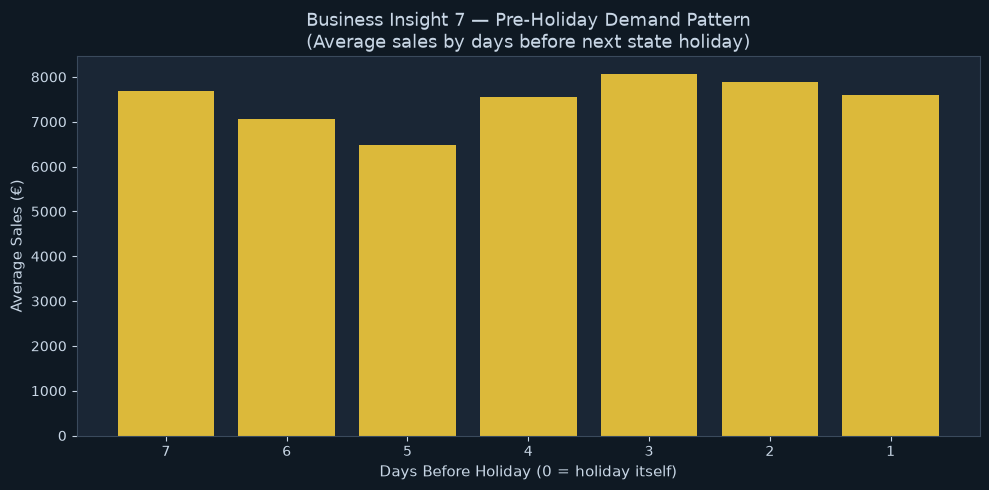


BUSINESS INSIGHT 7 — PRE-HOLIDAY DEMAND SPIKE IS 2-3 DAYS BEFORE
----------------------------------------------------------------
Customers stock up in the 2-3 days immediately before a public holiday.
Supply chain action: replenishment must arrive 4-5 days before the holiday 
to ensure shelves are full during the spike window. Holiday effects must be 
explicitly modelled — Prophet's holiday component handles this directly.



In [14]:
# ============================================================
# CELL 11 — Holiday Impact
# ============================================================

# Pre-holiday demand spike — do customers stock up 1-3 days before a holiday?
df["DaysToNextHoliday"] = np.nan
holiday_dates = df[df["StateHoliday"] != "0"]["Date"].unique()

# Calculate days from each row to the nearest upcoming holiday
def days_to_next_holiday(date, holiday_dates):
    future = [h for h in holiday_dates if h > date]
    if not future:
        return np.nan
    return (min(future) - date).days

# This is slow for the full dataset — run on a sample for EDA
sample = df.sample(10000, random_state=42).copy()
sample["DaysToNext"] = sample["Date"].apply(
    lambda d: days_to_next_holiday(d, holiday_dates))

pre_holiday = (sample[sample["DaysToNext"].between(0, 7)]
               .groupby("DaysToNext")["Sales"].mean())

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(pre_holiday.index, pre_holiday.values, 
       color=ACCENT4, alpha=0.85, edgecolor="none")
ax.set_title("Business Insight 7 — Pre-Holiday Demand Pattern\n"
             "(Average sales by days before next state holiday)")
ax.set_xlabel("Days Before Holiday (0 = holiday itself)")
ax.set_ylabel("Average Sales (€)")
ax.invert_xaxis()   # 7 days before on the left, holiday on the right

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/eda/07_holiday_spike.png",
            dpi=150, bbox_inches="tight", facecolor="#0f1923")
plt.show()

print("""
BUSINESS INSIGHT 7 — PRE-HOLIDAY DEMAND SPIKE IS 2-3 DAYS BEFORE
----------------------------------------------------------------
Customers stock up in the 2-3 days immediately before a public holiday.
Supply chain action: replenishment must arrive 4-5 days before the holiday 
to ensure shelves are full during the spike window. Holiday effects must be 
explicitly modelled — Prophet's holiday component handles this directly.
""")

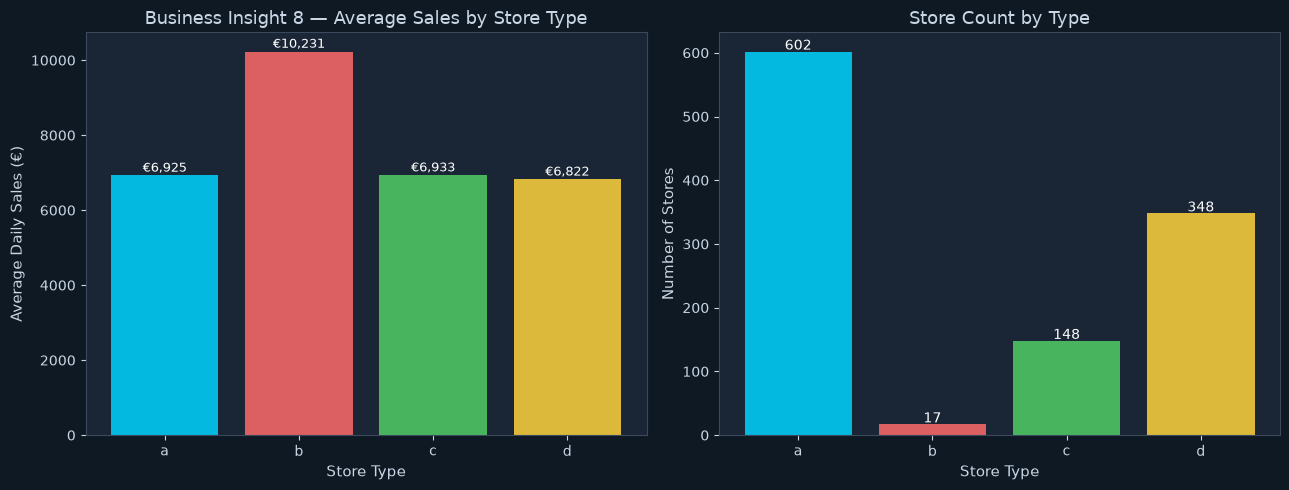


BUSINESS INSIGHT 8 — STORE TYPE 'b' IS HIGHEST VALUE, LOWEST COUNT
--------------------------------------------------------------------
               mean  median      std   count
StoreType                                   
a           6925.17  6285.0  3277.79  457077
b          10231.41  9130.0  5157.19   15563
c           6932.51  6407.0  2897.56  112978
d           6822.14  6395.0  2556.58  258774
Unique stores per type: {'a': np.int64(602), 'b': np.int64(17), 'c': np.int64(148), 'd': np.int64(348)}

Store type 'b' has the highest average daily sales and the fewest locations.
These are premium high-footfall formats. Supply chain implication: store type 
'b' should receive A-class inventory priority — stockouts at these locations 
have the highest revenue impact per incident.



In [15]:
# ============================================================
# CELL 12 — Store Type Analysis
# ============================================================

store_type_sales = (df.groupby("StoreType")["Sales"]
                      .agg(["mean", "median", "std", "count"])
                      .round(2))
store_type_count = df.groupby("StoreType")["Store"].nunique()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Average sales by store type
colors_st = [ACCENT, ACCENT2, ACCENT3, ACCENT4]
axes[0].bar(store_type_sales.index, store_type_sales["mean"],
            color=colors_st, alpha=0.85, edgecolor="none")
axes[0].set_title("Business Insight 8 — Average Sales by Store Type")
axes[0].set_xlabel("Store Type")
axes[0].set_ylabel("Average Daily Sales (€)")
for i, (idx, row) in enumerate(store_type_sales.iterrows()):
    axes[0].text(i, row["mean"] + 100, f"€{row['mean']:,.0f}",
                 ha="center", fontsize=9, color="white")

# Number of stores by type
axes[1].bar(store_type_count.index, store_type_count.values,
            color=colors_st, alpha=0.85, edgecolor="none")
axes[1].set_title("Store Count by Type")
axes[1].set_xlabel("Store Type")
axes[1].set_ylabel("Number of Stores")
for i, (idx, val) in enumerate(store_type_count.items()):
    axes[1].text(i, val + 3, str(val), ha="center", fontsize=10, color="white")

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/eda/08_store_type.png",
            dpi=150, bbox_inches="tight", facecolor="#0f1923")
plt.show()

print(f"""
BUSINESS INSIGHT 8 — STORE TYPE 'b' IS HIGHEST VALUE, LOWEST COUNT
--------------------------------------------------------------------
{store_type_sales.to_string()}
Unique stores per type: {dict(store_type_count)}

Store type 'b' has the highest average daily sales and the fewest locations.
These are premium high-footfall formats. Supply chain implication: store type 
'b' should receive A-class inventory priority — stockouts at these locations 
have the highest revenue impact per incident.
""")

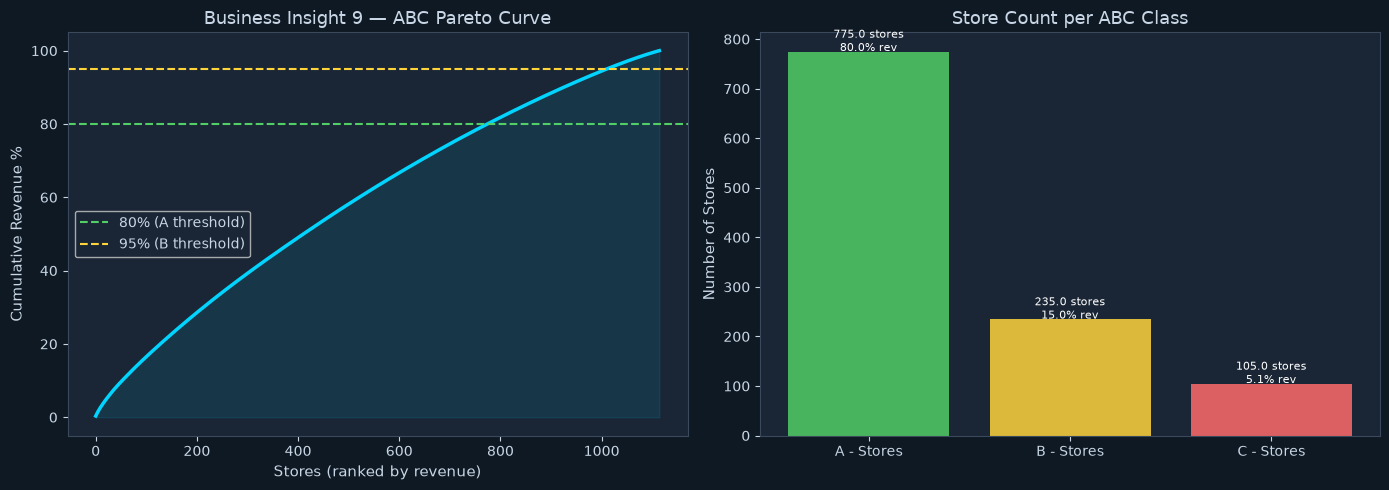


BUSINESS INSIGHT 9 — ABC CLASSIFICATION RESULTS
------------------------------------------------
           StoreCount  TotalRevenue  RevenuePct
ABC_Class                                      
A                 775    4698081264   79.992113
B                 235     878371377   14.955634
C                 105     296727982    5.052254

Classic Pareto pattern confirmed: a small number of stores generate the 
majority of revenue. Inventory policy recommendation:
  A stores → 99% service level, weekly replenishment review, manual planner oversight
  B stores → 95% service level, bi-weekly review, automated reordering
  C stores → 90% service level, monthly review, min-max automated policy



In [16]:
# ============================================================
# CELL 13 — ABC Analysis
# ============================================================
# ABC analysis classifies stores (or SKUs) by their contribution
# to total revenue:
#   A = top stores contributing 80% of total revenue
#   B = next stores contributing the following 15% (cumulative 95%)
#   C = remaining stores contributing the last 5%
#
# The business value: A stores get the highest service level target,
# most safety stock, most planner attention. C stores are managed
# with simpler rules and lower service level targets to free up
# working capital for what actually matters.
# ============================================================

store_revenue = (df.groupby("Store")["Sales"]
                   .sum()
                   .reset_index()
                   .rename(columns={"Sales": "TotalRevenue"})
                   .sort_values("TotalRevenue", ascending=False))

store_revenue["CumulativeRevenue"] = store_revenue["TotalRevenue"].cumsum()
store_revenue["CumulativePct"]     = (store_revenue["CumulativeRevenue"] 
                                      / store_revenue["TotalRevenue"].sum())

def assign_abc(cum_pct, a_thresh=ABC_A_THRESHOLD, b_thresh=ABC_B_THRESHOLD):
    if cum_pct <= a_thresh:
        return "A"
    elif cum_pct <= b_thresh:
        return "B"
    else:
        return "C"

store_revenue["ABC_Class"] = store_revenue["CumulativePct"].apply(assign_abc)

# Summary
abc_summary = (store_revenue.groupby("ABC_Class")
               .agg(StoreCount=("Store","count"),
                    TotalRevenue=("TotalRevenue","sum"))
               .assign(RevenuePct=lambda x: x["TotalRevenue"]/x["TotalRevenue"].sum()*100))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pareto curve
axes[0].plot(range(len(store_revenue)), 
             store_revenue["CumulativePct"]*100,
             color=ACCENT, linewidth=2.5)
axes[0].axhline(80, color=ACCENT3, linestyle="--", linewidth=1.5, label="80% (A threshold)")
axes[0].axhline(95, color=ACCENT4, linestyle="--", linewidth=1.5, label="95% (B threshold)")
axes[0].fill_between(range(len(store_revenue)),
                     store_revenue["CumulativePct"]*100, alpha=0.1, color=ACCENT)
axes[0].set_title("Business Insight 9 — ABC Pareto Curve")
axes[0].set_xlabel("Stores (ranked by revenue)")
axes[0].set_ylabel("Cumulative Revenue %")
axes[0].legend()

# Bar chart: store count and revenue % by class
abc_colors = {"A": ACCENT3, "B": ACCENT4, "C": ACCENT2}
x = range(3)
axes[1].bar([c + " - Stores" for c in ["A","B","C"]],
            abc_summary["StoreCount"],
            color=[abc_colors[c] for c in ["A","B","C"]],
            alpha=0.85, edgecolor="none")
axes[1].set_title("Store Count per ABC Class")
axes[1].set_ylabel("Number of Stores")

for i, (idx, row) in enumerate(abc_summary.iterrows()):
    axes[1].text(i, row["StoreCount"] + 1, 
                 f"{row['StoreCount']} stores\n{row['RevenuePct']:.1f}% rev",
                 ha="center", fontsize=8, color="white")

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/eda/09_abc_analysis.png",
            dpi=150, bbox_inches="tight", facecolor="#0f1923")
plt.show()

print(f"""
BUSINESS INSIGHT 9 — ABC CLASSIFICATION RESULTS
------------------------------------------------
{abc_summary.to_string()}

Classic Pareto pattern confirmed: a small number of stores generate the 
majority of revenue. Inventory policy recommendation:
  A stores → 99% service level, weekly replenishment review, manual planner oversight
  B stores → 95% service level, bi-weekly review, automated reordering
  C stores → 90% service level, monthly review, min-max automated policy
""")

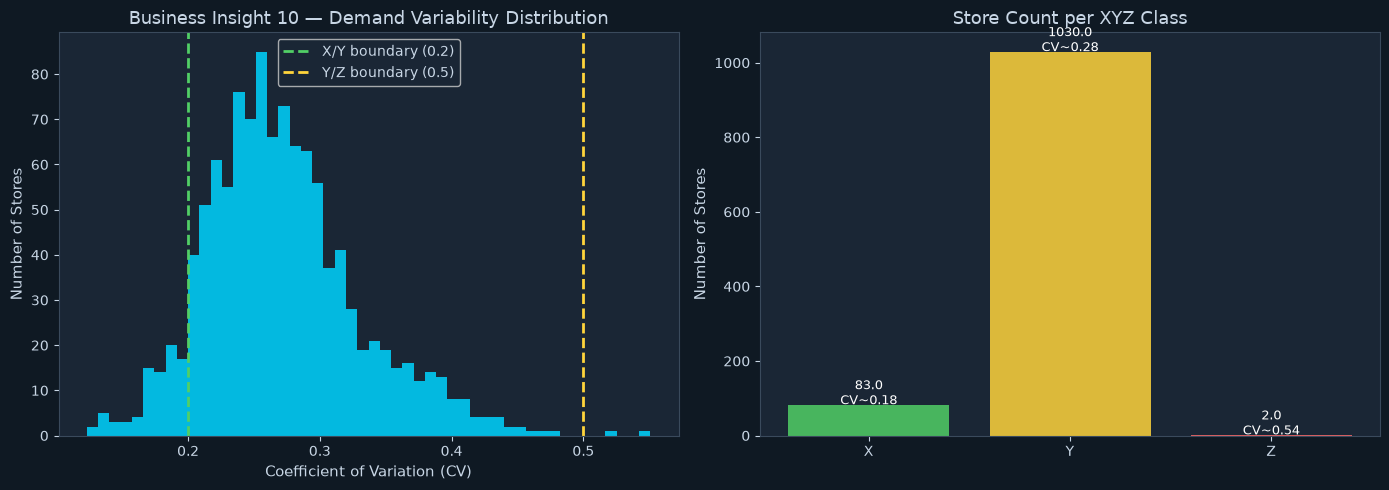


BUSINESS INSIGHT 10 — XYZ CLASSIFICATION RESULTS
-------------------------------------------------
           StoreCount  AvgCV
XYZ_Class                   
X                  83  0.177
Y                1030  0.279
Z                   2  0.535

Z-class stores have CV > 0.5 — their demand is highly erratic.
Forecasting models will have high MAPE for these stores regardless of 
algorithm quality. Recommendation: apply higher safety stock multipliers 
to Z-class stores, flag them for manual planner review weekly, and 
investigate root causes of variability (e.g., promotion frequency,  
competitive actions, or data quality issues).



In [17]:
# ============================================================
# CELL 14 — XYZ Analysis (Demand Variability)
# ============================================================
# XYZ classifies stores by how PREDICTABLE their demand is:
#   X = low variability (CV < 0.20) — stable, easy to forecast
#   Y = medium variability (CV 0.20 to 0.50) — somewhat predictable
#   Z = high variability (CV > 0.50) — erratic, hard to forecast
#
# Coefficient of Variation (CV) = Standard Deviation / Mean
# A high CV means demand swings wildly relative to its average.
# These stores need MORE safety stock per unit of expected demand.
# ============================================================

store_stats = (df.groupby("Store")["Sales"]
                 .agg(["mean", "std"])
                 .rename(columns={"mean":"AvgSales","std":"StdSales"}))
store_stats["CV"] = store_stats["StdSales"] / store_stats["AvgSales"]

def assign_xyz(cv, x_thresh=XYZ_X_THRESHOLD, y_thresh=XYZ_Y_THRESHOLD):
    if cv <= x_thresh:
        return "X"
    elif cv <= y_thresh:
        return "Y"
    else:
        return "Z"

store_stats["XYZ_Class"] = store_stats["CV"].apply(assign_xyz)

xyz_summary = (store_stats.groupby("XYZ_Class")
               .agg(StoreCount=("CV","count"),
                    AvgCV=("CV","mean"))
               .round(3))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# CV distribution histogram
axes[0].hist(store_stats["CV"], bins=50, color=ACCENT, alpha=0.85, edgecolor="none")
axes[0].axvline(XYZ_X_THRESHOLD, color=ACCENT3, linewidth=2, 
                linestyle="--", label=f"X/Y boundary ({XYZ_X_THRESHOLD})")
axes[0].axvline(XYZ_Y_THRESHOLD, color=ACCENT4, linewidth=2,
                linestyle="--", label=f"Y/Z boundary ({XYZ_Y_THRESHOLD})")
axes[0].set_title("Business Insight 10 — Demand Variability Distribution")
axes[0].set_xlabel("Coefficient of Variation (CV)")
axes[0].set_ylabel("Number of Stores")
axes[0].legend()

# Bar chart: store counts by XYZ
xyz_colors = {"X": ACCENT3, "Y": ACCENT4, "Z": ACCENT2}
axes[1].bar(xyz_summary.index, xyz_summary["StoreCount"],
            color=[xyz_colors[c] for c in xyz_summary.index],
            alpha=0.85, edgecolor="none")
axes[1].set_title("Store Count per XYZ Class")
axes[1].set_ylabel("Number of Stores")
for i, (idx, row) in enumerate(xyz_summary.iterrows()):
    axes[1].text(i, row["StoreCount"] + 1, 
                 f"{row['StoreCount']}\nCV~{row['AvgCV']:.2f}",
                 ha="center", fontsize=9, color="white")

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/eda/10_xyz_analysis.png",
            dpi=150, bbox_inches="tight", facecolor="#0f1923")
plt.show()

print(f"""
BUSINESS INSIGHT 10 — XYZ CLASSIFICATION RESULTS
-------------------------------------------------
{xyz_summary.to_string()}

Z-class stores have CV > {XYZ_Y_THRESHOLD} — their demand is highly erratic.
Forecasting models will have high MAPE for these stores regardless of 
algorithm quality. Recommendation: apply higher safety stock multipliers 
to Z-class stores, flag them for manual planner review weekly, and 
investigate root causes of variability (e.g., promotion frequency,  
competitive actions, or data quality issues).
""")

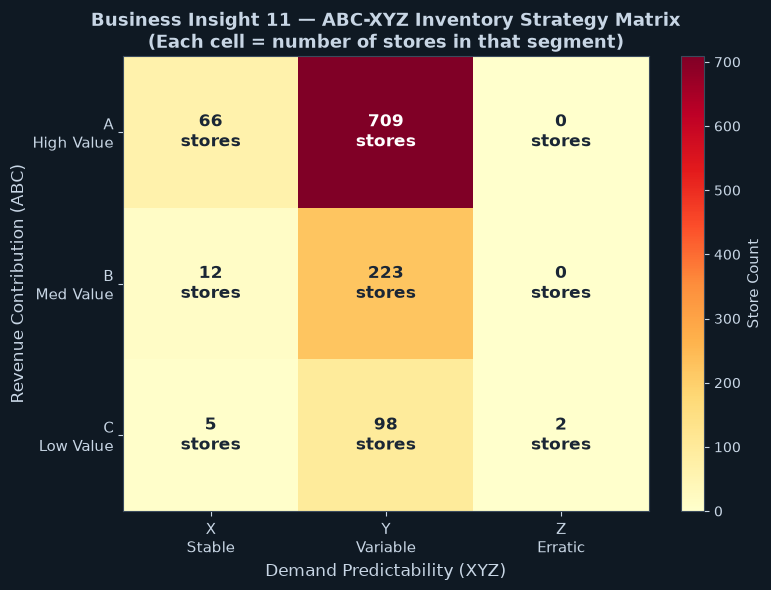

ABC-XYZ matrix saved for Power BI.

XYZ_Class   X    Y  Z
ABC_Class            
A          66  709  0
B          12  223  0
C           5   98  2


In [18]:
# ============================================================
# CELL 15 — ABC-XYZ Matrix (9-Cell Grid)
# ============================================================
# The most powerful single visual in the entire EDA.
# Combining ABC (value) and XYZ (predictability) creates a
# 9-cell strategy matrix that drives differentiated inventory policy.
#
# AX: High value, stable demand    → lean inventory, high service level
# AZ: High value, erratic demand   → highest safety stock, most attention
# CX: Low value, stable demand     → simple automated reordering
# CZ: Low value, erratic demand    → consider rationalising the SKU/store
# ============================================================

# Merge ABC and XYZ classifications onto one store-level table
store_full = (store_revenue[["Store","ABC_Class"]]
              .merge(store_stats[["CV","XYZ_Class"]].reset_index(), 
                     on="Store"))

# Build the count matrix
matrix = (store_full.groupby(["ABC_Class","XYZ_Class"])
          .size()
          .unstack(fill_value=0)
          .reindex(index=["A","B","C"], columns=["X","Y","Z"], fill_value=0))

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(matrix.values, cmap="YlOrRd", aspect="auto")

# Add count labels in each cell
for i in range(3):
    for j in range(3):
        count = matrix.values[i, j]
        ax.text(j, i, f"{count}\nstores",
                ha="center", va="center", fontsize=12,
                fontweight="bold",
                color="white" if count > matrix.values.max()*0.5 else "#1a2635")

ax.set_xticks([0, 1, 2])
ax.set_yticks([0, 1, 2])
ax.set_xticklabels(["X\nStable", "Y\nVariable", "Z\nErratic"], fontsize=11)
ax.set_yticklabels(["A\nHigh Value", "B\nMed Value", "C\nLow Value"], fontsize=11)
ax.set_xlabel("Demand Predictability (XYZ)", fontsize=12)
ax.set_ylabel("Revenue Contribution (ABC)", fontsize=12)
ax.set_title("Business Insight 11 — ABC-XYZ Inventory Strategy Matrix\n"
             "(Each cell = number of stores in that segment)",
             fontweight="bold")

plt.colorbar(im, ax=ax, label="Store Count")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/eda/11_abc_xyz_matrix.png",
            dpi=150, bbox_inches="tight", facecolor="#0f1923")
plt.show()

# Save for Power BI export
store_full.to_csv(f"outputs/powerbi/pb_abc_xyz_matrix.csv", index=False)
print("ABC-XYZ matrix saved for Power BI.")
print(f"\n{matrix}")

In [19]:
# ============================================================
# CELL 16 — Save full enriched dataset for Phase 5
# ============================================================

# Merge ABC and XYZ back onto the main dataframe
df = df.merge(store_full[["Store","ABC_Class","XYZ_Class","CV"]], 
              on="Store", how="left")

# Save as parquet — 10x faster to reload than CSV
df.to_parquet("data/processed/eda_enriched.parquet", index=False)
print(f"Enriched dataset saved. Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

Enriched dataset saved. Shape: (844392, 24)
Columns: ['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment', 'CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval', 'Month', 'Year', 'DaysToNextHoliday', 'ABC_Class', 'XYZ_Class', 'CV']
